# 03_03_CDEM_Raw_Elevation_Data

## 1.Introduction

    This notebook focuses on loading and inspecting the raw data obtained from the Canadian Digital Elevation Model (CDEM).

Unlike the previous boundary layer, these datasets represent continuous terrain surfaces and form the foundation for later hydrological analysis.

The primary objective is to examine the structure, coordinate system, and characteristics of the elevation data before clipping it to the Waterloo Region study area.

**Data Source: S2**

The dataset includes multiple derived terrain products:
- DEM (base elevation surface)
- Hillshade (visual terrain relief)
- Slope (gradient intensity)
- Aspect (slope direction)
- Color relief (visual interpretation layer)

## 2. Imports

Import core geospatial and visualization libraries used in this notebook:

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

## 3. Elevation Data File Paths

In [6]:
base_path = "../../data/Elevation Data/dataset/"

dem_path = base_path + "DEM.tif"
hillshade_path = base_path + "HILLSHADE.tif"
slope_path = base_path + "SLOPE.tif"
aspect_path = base_path + "ASPECT.tif"
color_path = base_path + "COLOR.tif"

## 4. Load Datasets

In [7]:
# Open datasets

dem = rasterio.open(dem_path)

hillshade = rasterio.open(hillshade_path)

slope = rasterio.open(slope_path)

aspect = rasterio.open(aspect_path)

color = rasterio.open(color_path)

## 5. Dataset Inspection

Before clipping the terrain model to the study area, it is useful to inspect the coordinate system, spatial extent, resolution, and elevation range of the raw elevation dataset.

These properties help verify that the data are suitable for analysis and provide important information for later processing steps.

### Coordinate Metadata

In [12]:
print("Coordinate System:")
print(dem.crs)

print()

print("Bounds:")
print(dem.bounds)

print()

minx, miny, maxx, maxy = dem.bounds

print("Minimum Longitude:", minx)
print("Minimum Latitude:", miny)

print()

print("Maximum Longitude:", maxx)
print("Maximum Latitude:", maxy)

Coordinate System:
EPSG:4617

Bounds:
BoundingBox(left=-81.21781573192465, bottom=42.86907459975246, right=-79.81115756865935, top=43.99362182764753)

Minimum Longitude: -81.21781573192465
Minimum Latitude: 42.86907459975246

Maximum Longitude: -79.81115756865935
Maximum Latitude: 43.99362182764753

Resolution:
(0.000381725417439701, 0.00038172003662425956)

Raster Size:
3685 x 2946


### File Metadata

In [14]:
print("Resolution:")
print(dem.res)

print()

print("Raster Size:")
print(dem.width, "x", dem.height)

Resolution:
(0.000381725417439701, 0.00038172003662425956)

Raster Size:
3685 x 2946


### Elevation Statistics

The DEM stores elevation values in meters above sea level.

Examining the range of elevations provides a first overview of the terrain and helps identify possible issues such as missing data or unexpected values.

In [16]:
import numpy as np

dem_data = dem.read(1)

nodata = dem.nodata

if nodata is not None:
    dem_data = np.where(dem_data == nodata, np.nan, dem_data)

print("Minimum elevation (m):", np.nanmin(dem_data))
print("Maximum elevation (m):", np.nanmax(dem_data))
print("Mean elevation (m):", np.nanmean(dem_data))

Minimum elevation (m): 70.0
Maximum elevation (m): 522.0
Mean elevation (m): 325.83436437512495


## 6. Example Terrain Products

The elevation extraction includes several derived products.

Only the DEM and hillshade layers are displayed here as examples. Additional products such as slope, aspect, and color relief will be examined in later notebooks.

In [17]:
### Display DEM Data

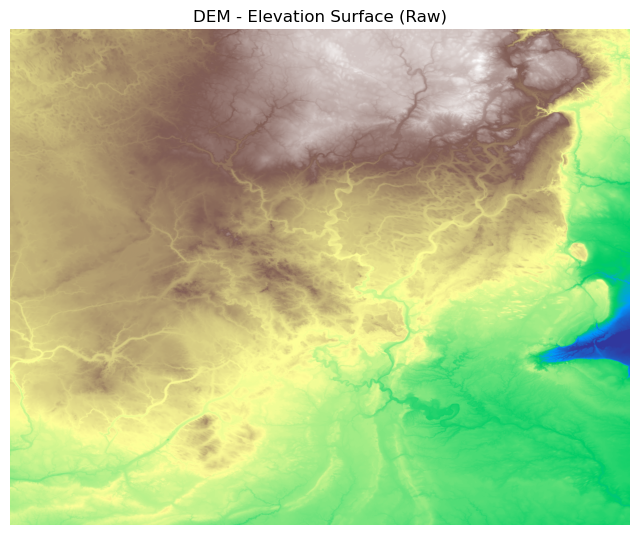

In [18]:
plt.figure(figsize=(8,8))

plt.imshow(dem_data, cmap="terrain")

plt.title("DEM - Elevation Surface (Raw)")
plt.axis("off")

plt.show()

### Display Hillshade Data

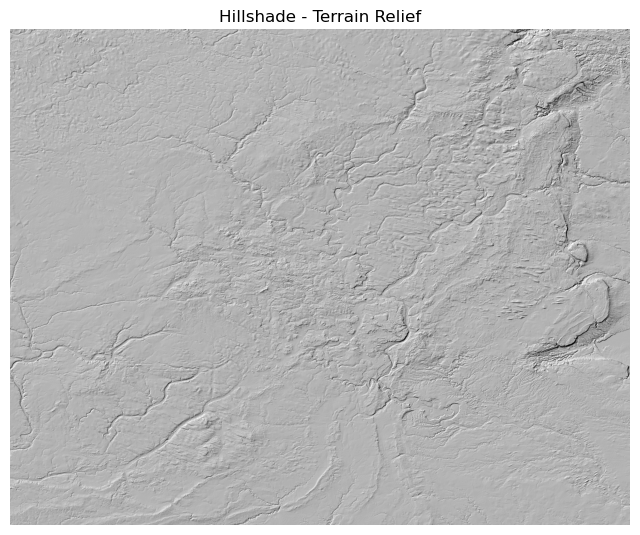

In [19]:
plt.figure(figsize=(8,8))

plt.imshow(hillshade.read(1), cmap="gray")

plt.title("Hillshade - Terrain Relief")

plt.axis("off")

plt.show()